In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [54]:
data=pd.read_csv("diamonds.csv")

## Preveiw data

In [55]:
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.0,0.23,Ideal,E,SI2,61.5,NaN,326.0,3.95,3.98,2.43
1,2.0,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,3.0,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,4.0,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,5.0,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


## Dropping unwanted columns data.drop(columns=['Unnamed: 0'], inplace=True)

In [56]:
data.drop(columns=["Unnamed: 0"],inplace=True)

##  Data info

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    52340 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    52347 non-null  float64
 5   table    52322 non-null  float64
 6   price    52322 non-null  float64
 7   x        52322 non-null  float64
 8   y        52322 non-null  float64
 9   z        52322 non-null  float64
dtypes: float64(7), object(3)
memory usage: 4.1+ MB


### Exploratory data analysis
    . Carat is diamond weigh
    . Cut How well the diamond was cut
    . Color Diamond color grade
    . Clarity How clean the diamond is inside
    . Depth How tall the diamond is relative to width
    . Table Width of top surface.
    . Price What we want to predict.
    volume = length * width * height

## Checking datatypes

In [58]:
data.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price      float64
x          float64
y          float64
z          float64
dtype: object

## Data stracture

In [59]:
data.shape

(53940, 10)

## Statistical Information

In [60]:
data.std(numeric_only=True)

carat       0.671992
depth       2.032185
table       2.234341
price    3984.285875
x           1.120954
y           1.142875
z           0.706309
dtype: float64

In [61]:
data.mean(numeric_only=True)

carat       0.846470
depth      61.896182
table      57.456504
price    3928.312450
x           5.730627
y           5.734616
z           3.538869
dtype: float64

In [62]:
data.median(numeric_only=True)

carat       0.71
depth      61.90
table      57.00
price    2400.00
x           5.70
y           5.71
z           3.53
dtype: float64

In [63]:
## THIS SHOW SKEWNESS OF MY DATA THEY ARE MOSLTY RIGHT SKEW

In [64]:
data.skew(numeric_only=True)

carat    3.786736
depth    3.369175
table    0.795724
price    1.619198
x        0.376434
y        2.493296
z        1.554195
dtype: float64

## Checking null values

In [65]:
data.isnull().any()
# this tells there is missing data except three columns cut color clarity

carat       True
cut        False
color      False
clarity    False
depth       True
table       True
price       True
x           True
y           True
z           True
dtype: bool

## Percentage of missing values

In [66]:
(data.isnull().sum()/len(data))*100

carat      2.966259
cut        0.000000
color      0.000000
clarity    0.000000
depth      2.953281
table      2.999629
price      2.999629
x          2.999629
y          2.999629
z          2.999629
dtype: float64

In [67]:
(data.isnull().sum().sum()/data.size)*100

np.float64(2.0917686318131254)

##  Handling Missing values

In [68]:
for col in ["carat","depth","table","price","x","y","z"]:
    data[col] = data[col].fillna(data[col].median())

Missing value analysis showed that approximately 3% of the numerical columns contained missing data, while categorical columns had no missing values. Since the percentage was relatively small, missing numerical values were handled using median imputation to preserve the dataset size and reduce the influence of outliers

In [69]:
data.shape


(53940, 10)

## Checking inconsisten data using values_count by column

In [70]:
data["cut"].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

## Checking relationships of the columns 
We can see here carat ,price,x ,y,z they have strong relationship so they are important columns to me

In [71]:
data.corr(numeric_only=True)

,carat,depth,table,price,x,y,z
carat,1.000000,0.018526,0.121426,0.623146,0.661517,0.646455,0.648127
depth,0.018526,1.000000,-0.202573,-0.006758,-0.017977,-0.021420,0.062668
table,0.121426,-0.202573,1.000000,0.122793,0.189404,0.177289,0.145987
price,0.623146,-0.006758,0.122793,1.000000,0.854113,0.837358,0.834348
x,0.661517,-0.017977,0.189404,0.854113,1.000000,0.944003,0.940449
y,0.646455,-0.021420,0.177289,0.837358,0.944003,1.000000,0.922979
z,0.648127,0.062668,0.145987,0.834348,0.940449,0.922979,1.000000


## Showing if there is outlier in each column

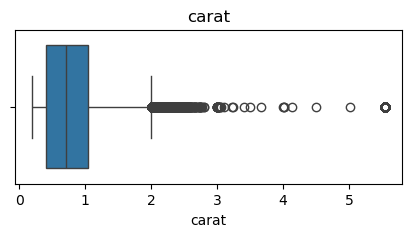

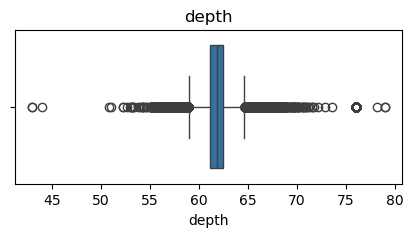

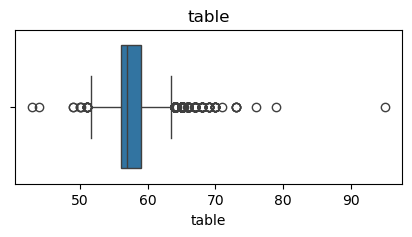

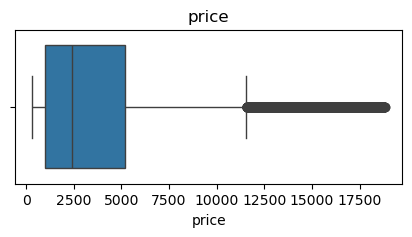

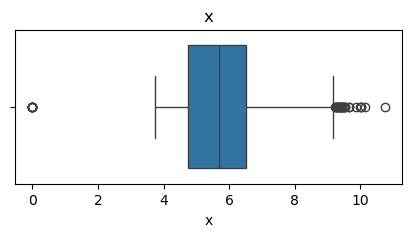

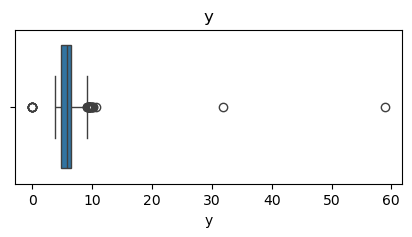

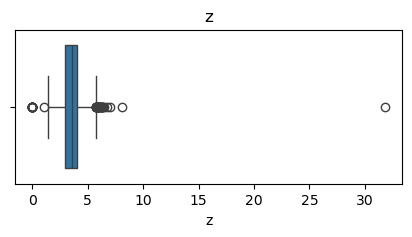

In [72]:
numerical_columns = data.select_dtypes(include='number')
for col in numerical_columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=numerical_columns[col])
    plt.title(col)
    plt.show()

## Box blot explanations
1. Although the carat column contained upper outliers, the values were retained because they represent genuine large diamonds rather than errors. Removing them could lead to loss of important information
2. The depth column values near 43–45 and near 78–79 look suspicious.



## Detecting (identifying) unusual values

In [73]:
outlier_indices = set()

for col in numerical_columns.columns:
    Q1 = numerical_columns[col].quantile(0.25)
    Q3 = numerical_columns[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = numerical_columns[
        (numerical_columns[col] < lower_bound) |
        (numerical_columns[col] > upper_bound)
    ]

    outlier_indices.update(outliers.index)

print("Total Unique Outliers:", len(outlier_indices))

Total Unique Outliers: 7783


# Handling Outliers

## Handling Outliers in Dimension Columns (x, y, z)
The x, y, and z columns represent diamond dimensions. Boxplot analysis revealed impossible values such as zeros and unrealistic extreme measurements. Since these values are not physically meaningful for diamonds, rows containing invalid dimensions were removed using conditional filtering.

In [74]:
print(f"Before {data.shape}")
data = data[
    (data["x"] > 0) & (data["x"] < 20) &
    (data["y"] > 0) & (data["y"] < 20) &
    (data["z"] > 0) & (data["z"] < 10)
]
print(f"After {data.shape}")

Before (53940, 10)
After (53917, 10)


## Handling Outliers in  Columns (depth, table)
Boxplot analysis showed upper and lower outliers in the depth and table columns. Since these columns represent diamond proportions rather than physical dimensions, outliers were handled using IQR-based capping instead of removing rows.

In [75]:
for col in ["depth", "table"]:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)


### Cheching duplicate and droping duplicates

In [76]:
# this shows i have 93 duplicate row and its small
data.duplicated().sum()
data.drop_duplicates(inplace=True)

In [77]:
#after remvoved duplicates
data.duplicated().sum()

np.int64(0)

# Feature enginering

In [78]:
data["Volume"]=data["x"] * data["y"] * data["z"]

In [79]:
print(f"After adding volume {data.shape}")

After adding volume (53820, 11)


### Feature Encoding🔥

In [80]:
## using oridinal encoder 

In [81]:
categorical_columns = ["cut", "color", "clarity"]

In [82]:
from sklearn.preprocessing import OrdinalEncoder

In [83]:
encoder = OrdinalEncoder(categories=[
    ["Fair", "Good", "Very Good", "Premium", "Ideal"],  # cut
    ["J", "I", "H", "G", "F", "E", "D"],               # color (J=worst, D=best)
    ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]  # clarity
])

In [84]:
data[categorical_columns] = encoder.fit_transform(data[categorical_columns])

In [85]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,Volume
0,0.23,4.0,5.0,1.0,61.5,57.0,326.0,3.95,3.98,2.43,38.202030
1,0.21,3.0,5.0,2.0,59.8,61.0,326.0,3.89,3.84,2.31,34.505856
2,0.23,1.0,5.0,4.0,59.0,63.5,327.0,4.05,4.07,2.31,38.076885
3,0.29,3.0,1.0,3.0,62.4,58.0,334.0,4.20,4.23,2.63,46.724580
4,0.31,1.0,0.0,1.0,63.3,58.0,335.0,4.34,4.35,2.75,51.917250


<!-- ## A new feature called volume was engineered using the x, y, and z dimensions.
Since volume already captures the combined spatial information of these variables, the original dimension columns were removed to reduce redundancy and multicollinearity in the dataset. -->

In [86]:
# data = data.drop(["x", "y", "z"], axis=1)

# Exploratory Data Analysis (EDA)
Now analyze the cleaned data deeply.

### This shows that the price is left skew most data is on the left side 

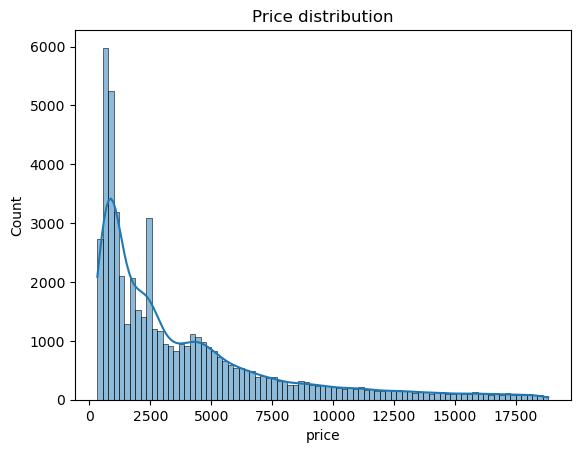

In [87]:
sns.histplot(data["price"],kde=True)
plt.title("Price distribution")
plt.show()

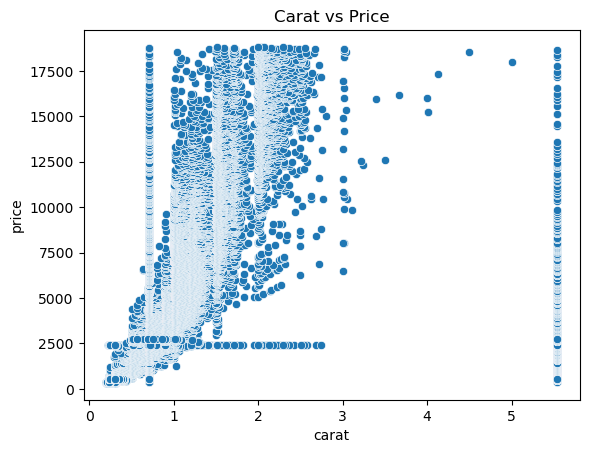

In [88]:
sns.scatterplot(x="carat", y="price", data=data)
plt.title("Carat vs Price")
plt.show()

As carat increases, the price generally increases too.
This means there is a positive correlation between carat and price

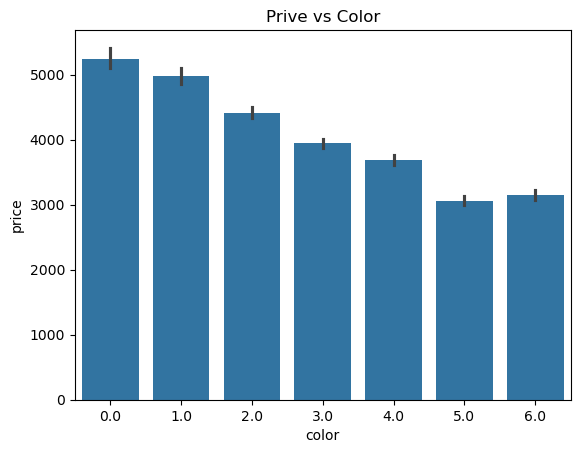

In [89]:
sns.barplot(x="color", y="price", data=data)
plt.title("Prive vs Color")
plt.show()

This chart displays the average price across different diamond color grades (E, I, J, H, F, G, D)
Highest Average Prices: Color grade J boasts the highest average price (exceeding $5,000),
closely followed by color grade I (around $5,000).
Lowest Average Prices: Color grades E and D have the lowest average prices, sitting just over $3,000.

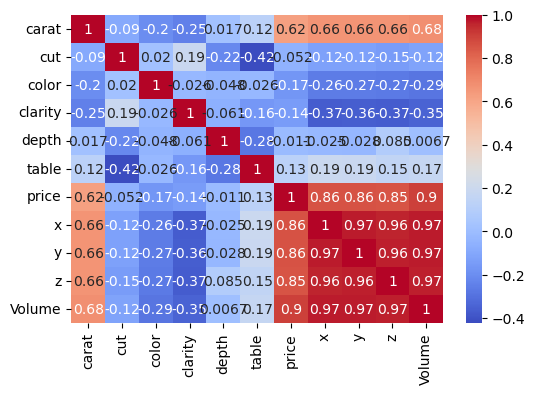

In [103]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

* There is an exceptionally strong positive correlation ($0.86$, $0.86$, $0.85$) between price and the physical dimensions (x, y, z).
* There is a strong positive correlation ($0.62$) between price and carat weight.
*  This confirms that as a diamond gets larger and heavier, its price    increases significantly.Multicollinearity Among Dimensions:
*  The dimensions x, y, and z are nearly perfectly correlated with each other ($0.96$ to $0.97$) and very strongly correlated with carat ($0.66$).
* This makes perfect intuitive sense: a diamond with a higher carat weight will naturally be larger in length, width, and depth  

## Train/Test Split

In [91]:
X = data.drop("price", axis=1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## StandardScaler


In [92]:
from sklearn.preprocessing import StandardScaler

# create scaler
scaler = StandardScaler()

# fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# use same scaler on test data
X_test_scaled = scaler.transform(X_test)

## Machine Learning Model Linear Regression

In [93]:
# Linear Regression
linear_model = LinearRegression()
## Training the model (giving Sample Q & A)
linear_model.fit(X_train, y_train)

## Testing the model
linear_predictions = linear_model.predict(X_test)

print("LINEAR REGRESSION")
print("R2 Score:", r2_score(y_test, linear_predictions))
print("MAE:", mean_absolute_error(y_test, linear_predictions))

LINEAR REGRESSION
R2 Score: 0.8663127139935334
MAE: 869.8007455271226


In [94]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("RANDOM FOREST")
print("R2 Score:", r2_score(y_test, rf_predictions))
print("MAE:", mean_absolute_error(y_test, rf_predictions))

RANDOM FOREST
R2 Score: 0.9401217509668041
MAE: 395.2109471054308


## Checking my model perfomance

In [99]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Linear": linear_predictions,
    "RandomForest": rf_predictions

})

print(comparison.head(10))


        Actual        Linear  RandomForest
50958   2323.0   4471.794182       3567.04
37306    979.0   2088.238740        960.92
30721    738.0   1289.131988        907.32
12953   5387.0   8028.195719       8045.94
3891    2400.0   4339.667559       3322.22
23068  11103.0  10376.309160      10376.64
11422   5002.0   5099.568720       4494.72
2012    3103.0   3924.719338       3090.64
53874   2745.0   3536.209612       2897.54
42195   1287.0    885.750257       1306.00


## Overfitting check

In [101]:
print("Train R2:", rf_model.score(X_train, y_train))
print("Test R2:", rf_model.score(X_test, y_test))

Train R2: 0.990384962412007
Test R2: 0.9401217509668041
